# Análisis Exploratorio de Datos (EDA) - Espesador 1

Este notebook realiza el análisis exploratorio de datos para el Espesador 1 utilizando el archivo de datos históricos de operación.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga de Datos

Cargamos el archivo CSV correspondiente al Espesador 1, definiendo la primera columna (fecha/hora) como índice temporal.

In [ ]:
# Ruta al archivo CSV de datos crudos
csv_path = "data/raw/Data_Esp1_20260613_1853.csv"

# Cargar los datos en un DataFrame de pandas
print(f"Cargando datos desde: {csv_path}...")
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
print("¡Datos cargados con éxito!")

# Mostrar dimensiones del DataFrame
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")

## 2. Vista Previa y Estructura de los Datos

In [ ]:
# Visualizar las primeras 5 filas
df.head()

In [ ]:
# Información general del DataFrame (tipos de datos y memoria)
df.info()

## 3. Estadísticas Descriptivas

Obtenemos un resumen estadístico de las variables operacionales ($x_i$ son variables de entrada, $y_i$ son variables de salida o de control).

In [ ]:
# Resumen estadístico descriptivo
df.describe().T

## 4. Análisis de Valores Nulos

In [ ]:
# Calcular la cantidad y porcentaje de valores nulos por columna
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

df_missing = pd.DataFrame({
    'Valores Nulos': missing_values,
    'Porcentaje (%)': missing_percentage
}).sort_values(by='Valores Nulos', ascending=False)

df_missing

## 5. Visualización del Perfil de Datos

Graficamos la matriz de correlación para entender la relación entre las diferentes variables.

In [ ]:
# Matriz de correlación
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables del Espesador 1", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Análisis de Exclusión Mutua entre (x1, x3) y (x2, x4)

El usuario ha observado que las columnas `x1`, `x3` y `x2`, `x4` se excluyen mutuamente (es decir, cuando un grupo tiene valores mayores a cero, el otro grupo es cero). En esta sección validamos cuantitativa y visualmente esta hipótesis.

In [ ]:
# 1. Definir condiciones de actividad para cada grupo
grupo_A_activo = (df['x1'] > 0) | (df['x3'] > 0)
grupo_B_activo = (df['x2'] > 0) | (df['x4'] > 0)

# Calcular estadísticas de exclusión
total_filas = len(df)
solo_A = df[grupo_A_activo & ~grupo_B_activo]
solo_B = df[~grupo_A_activo & grupo_B_activo]
ambos_cero = df[~grupo_A_activo & ~grupo_B_activo]
solapamiento = df[grupo_A_activo & grupo_B_activo]

print(f"Total de registros: {total_filas}")
print(f"Registros donde SOLO (x1 o x3) está activo: {len(solo_A)} ({len(solo_A)/total_filas*100:.2f}%)")
print(f"Registros donde SOLO (x2 o x4) está activo: {len(solo_B)} ({len(solo_B)/total_filas*100:.2f}%)")
print(f"Registros donde AMBOS grupos están en cero: {len(ambos_cero)} ({len(ambos_cero)/total_filas*100:.2f}%)")
print(f"Registros con SOLAPAMIENTO (ambos activos > 0): {len(solapamiento)} ({len(solapamiento)/total_filas*100:.2f}%)")

# Conclusión cuantitativa
if len(solapamiento) == 0:
    print("\n¡Confirmado! Existe una EXCLUSIÓN MUTUA perfecta (0% de solapamiento) entre (x1, x3) y (x2, x4).")
else:
    print(f"\nExiste un solapamiento menor de {len(solapamiento)} filas ({len(solapamiento)/total_filas*100:.4f}%). La exclusión mutua es casi perfecta.")

### Visualización de la Alternancia

Para visualizar cómo alternan estos dos grupos de variables en el tiempo, tomaremos una muestra de 1440 observaciones consecutivas (equivalente a 1 día si la frecuencia es de 1 minuto).

In [ ]:
# Buscar un periodo donde ocurra la alternancia
# Graficamos una muestra de 1440 puntos
muestra = df.iloc[1000:2440]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Graficar Grupo A (x1, x3)
ax1.plot(muestra.index, muestra['x1'], label='x1', color='tab:blue', alpha=0.8)
ax1.plot(muestra.index, muestra['x3'], label='x3', color='tab:cyan', alpha=0.8)
ax1.set_title("Grupo A: Variables x1 y x3")
ax1.set_ylabel("Valor")
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Graficar Grupo B (x2, x4)
ax2.plot(muestra.index, muestra['x2'], label='x2', color='tab:red', alpha=0.8)
ax2.plot(muestra.index, muestra['x4'], label='x4', color='tab:orange', alpha=0.8)
ax2.set_title("Grupo B: Variables x2 y x4")
ax2.set_ylabel("Valor")
ax2.set_xlabel("Tiempo")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Visualización de la Exclusión Mutua / Alternancia entre Variables de Entrada", fontsize=16)
plt.tight_layout()
plt.show()

## 7. Creación de CSV para cada linea (PP08/PP07)

En esta sección, calculamos las matrices de correlación para cada uno de los subconjuntos de datos (Modo Línea 1, Modo Línea 2 y Solapamiento). Para facilitar la interpretación física, renombramos los alias `x` e `y` a sus respectivos tags de instrumentación reales y descripciones operativas basándonos en [espesador_desc.txt](../docs/espesador_desc.txt).

In [ ]:
import os

# Definir la ruta de salida para los archivos procesados
output_dir = "/home/fito/Proyects/data4Espesadores/data/processed"
os.makedirs(output_dir, exist_ok=True)

# 1. df_solo_A (eliminando columnas inactivas x2 y x4)
df_solo_A_proc = solo_A.drop(columns=['x2', 'x4','y5'], errors='ignore')
df_solo_A_proc.to_csv(os.path.join(output_dir, "df_solo_A.csv"))

# 2. df_solo_B (eliminando columnas inactivas x1 y x3)
df_solo_B_proc = solo_B.drop(columns=['x1', 'x3','y4'], errors='ignore')
df_solo_B_proc.to_csv(os.path.join(output_dir, "df_solo_B.csv"))

# 3. df_ambos_cero (sin cambios en las columnas)
ambos_cero.to_csv(os.path.join(output_dir, "df_ambos_cero.csv"))

# 4. df_solapamiento (sin cambios en las columnas)
solapamiento.to_csv(os.path.join(output_dir, "df_solapamiento.csv"))

print("Proceso completado. Los 4 archivos CSV se guardaron exitosamente.")


In [11]:
import numpy as np
import pandas as pd


def limpiar_dataset_industrial_v3(df):
    df_procesado = df.copy()

    # --- 1. PREPARACIÓN Y CONVERSIÓN DE TIEMPO (Requerido para Splines) ---
    # Identificar columna temporal automática (Unnamed: 0 o timestamp)
    col_tiempo = df_procesado.columns[0] if (df_procesado.columns[0].startswith("Unnamed:") or df_procesado.columns[0] == "") else "timestamp"
    
    if col_tiempo in df_procesado.columns:
        df_procesado.rename(columns={col_tiempo: "timestamp"}, inplace=True)
        df_procesado["timestamp"] = pd.to_datetime(df_procesado["timestamp"])
        # Asegurar índice estrictamente creciente y único
        df_procesado = df_procesado.sort_values("timestamp").reset_index(drop=True)

    # --- DICCIONARIO DE LÍMITES FÍSICOS REALES COMPLETO ---
    limites_fisicos = {
        "x1": (0.0, 100.0),    # Hz (Bomba L1)
        "x2": (0.0, 100.0),    # Hz (Cizallamiento L2) <-- AGREGADO
        "x3": (0.0, 100.0),    # Hz (Cizallamiento L1)
        "x4": (0.0, 100.0),    # Hz (Bomba L2)
        "x5": (0.0, 100.0),   # Nivel Cajón %
        "x6": (0.0, 5000.0),  # Flujo Alimento
        "x7": (0.0, 100.0),   # Válvula %
        "x8": (0.0, 10.0),     # Floculante
        "x9": (0.0, 100.0),   # Piscina 1 %
        "x10": (0.0, 100.0),  # Piscina 2 %
        "y1": (0.0, 100.0),    # BedMass t
        "y2": (0.0, 7.0),    # Interfase m
        "y3": (0.0, 100.0),   # Torque %
        "y4": (1.0, 2.0),     # Densidad L1 <-- AGREGADO
        "y5": (1.0, 2.0),     # Densidad L2
        "y6": (0.0, 10000.0),  # Flujo Overflow
        "y7": (0.0, 100.0),   # TK001 %
        "y8": (0.0, 100.0),   # TK002 %
    }

    columnas_rapidas = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8", "y6"]

    for col in df_procesado.columns:
        if col == "timestamp":
            continue

        # CAPA 1: Filtro de Límites Físicos Inicial (Hard Bounds)
        if col in limites_fisicos:
            min_val, max_val = limites_fisicos[col]
            fuera_de_limite = (df_procesado[col] < min_val) | (df_procesado[col] > max_val)
            df_procesado.loc[fuera_de_limite, col] = np.nan

        # CAPA 2: Filtro de Hampel sobre datos restantes
        ventana = 15 if col in columnas_rapidas else 31
        n_sigmas = 3 if col in columnas_rapidas else 4

        mediana_movil = df_procesado[col].rolling(window=ventana, center=True).median()
        
        # MAD rápido
        mad_movil = (
            df_procesado[col]
            .rolling(window=ventana, center=True)
            .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
        )

        limite = n_sigmas * 1.4826 * mad_movil
        outliers_hampel = np.abs(df_procesado[col] - mediana_movil) > limite
        df_procesado.loc[outliers_hampel, col] = np.nan

        # CAPA 3: Interpolación Inteligente
        # Relleno cúbico en baches de hasta 15 min; lineal para baches más largos
        df_procesado[col] = df_procesado[col].interpolate(method="cubicspline", limit=15)
        df_procesado[col] = df_procesado[col].interpolate(method="linear")

        # CAPA 4: Control de bordes final (ffill y bfill por seguridad)
        df_procesado[col] = df_procesado[col].interpolate(method="linear", limit_direction="both")

        # CAPA 5: Clipping Final de Seguridad
        if col in limites_fisicos:
            min_val, max_val = limites_fisicos[col]
            df_procesado[col] = df_procesado[col].clip(lower=min_val, upper=max_val)

    return df_procesado

df_b = pd.read_csv('data/processed/df_solo_B.csv')
df_b_limpio = limpiar_dataset_industrial_v3(df_b)


In [17]:
df_b_limpio.head(50)

,timestamp,x2,x4,x5,x6,x7,x8,x9,x10,y1,y2,y3,y5,y6,y7,y8
0,2025-01-02 10:19:00,45.049240,22.030922,45.817169,916.228455,0.0,0.0,11.576891,90.342438,60.530003,1.759705,39.745609,1.677724,1056.997192,29.536842,29.707390
1,2025-01-02 10:20:00,45.141129,22.105076,46.362877,931.942200,0.0,0.0,11.579324,90.432541,60.678059,1.801719,40.630405,1.641888,1058.133301,29.533218,29.888062
2,2025-01-02 10:21:00,45.233017,22.179230,45.599293,909.865662,0.0,0.0,11.581757,90.522644,60.867725,1.806346,39.211090,1.612946,1059.269531,29.529593,30.168745
3,2025-01-02 10:22:00,45.324902,22.253384,45.452335,901.982788,0.0,0.0,11.584190,90.612747,61.057396,1.810973,40.206268,1.609226,1060.405762,29.525969,30.394310
4,2025-01-02 10:23:00,50.081375,22.327538,49.125038,1042.858398,0.0,0.0,11.586623,90.702850,61.247063,1.815600,40.056683,1.610554,1061.541870,29.522345,30.604990
5,2025-01-02 10:24:00,50.222527,25.750841,49.378506,1054.895630,0.0,0.0,11.589056,90.792953,61.436733,1.831760,41.079384,1.610739,1068.395020,29.518719,30.764727
6,2025-01-02 10:25:00,50.363678,25.365093,48.674110,1021.949463,0.0,0.0,11.591490,90.883057,61.626400,1.852705,41.049541,1.609790,1530.570312,29.515095,30.798820
7,2025-01-02 10:26:00,50.504833,20.159985,48.563541,1018.505127,0.0,0.0,11.593923,90.973160,61.593239,1.856771,39.549381,1.606933,1706.547638,29.511471,30.678593
8,2025-01-02 10:27:00,50.645985,29.040594,47.733841,985.215820,0.0,0.0,11.596355,91.063263,61.222885,1.860836,39.985382,1.606304,1538.251166,29.507847,30.523596
9,2025-01-02 10:28:00,50.787136,45.492802,47.133400,963.336731,0.0,0.0,11.598789,91.153366,60.852535,1.864901,39.496517,1.606496,1244.756754,29.504221,30.286377


In [13]:

df_b_limpio.to_csv('data/processed/df_b_limpio.csv', index=False)

                     TABLA COMPARATIVA DE LIMPIEZA DE OUTLIERS
Columna  Outliers Corregidos Min Original Min Limpio Max Original Max Limpio Std Original Std Limpio
     x2                  114         0.00       0.00        74.97      71.00         5.22       5.20
     x4                  311         0.00       0.00        62.99      64.09         7.10       7.09
     x5                 7026         0.00       0.00    55,961.40     100.00       116.45      15.88
     x6                 6201         0.00       0.00     6,268.06   5,000.00       552.91     549.03
     x7                  157         0.00       0.00       100.00     100.00        20.11      20.12
     x8                 3684         0.00       0.00         2.80       1.60         0.23       0.23
     x9                11027        -2.16       0.00        95.90     100.00        38.15      37.62
    x10                 2522        42.72      42.72       101.10     100.00        11.81      11.70
     y1                 8850

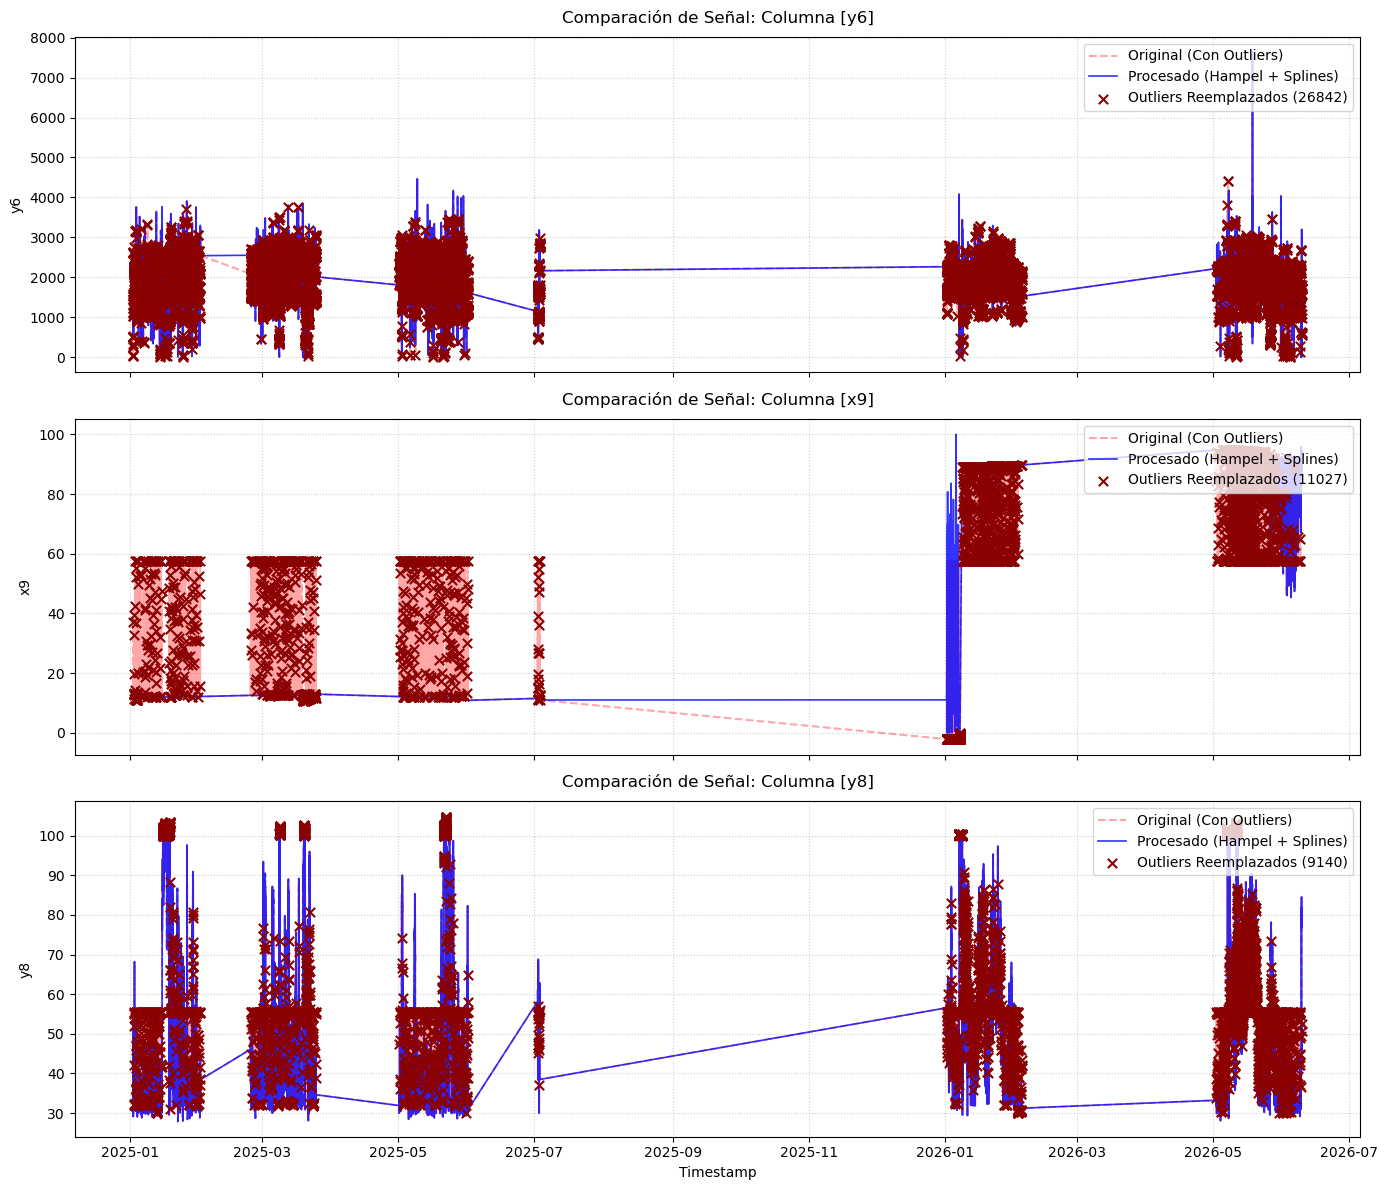

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def comprobar_y_graficar_outliers(df_original, df_limpio, columnas_a_comparar=None):
    """Compara estadísticamente y de forma visual los datasets antes y después

    de aplicar el pipeline de filtrado de Hampel + Splines.
    """
    df_orig = df_original.copy()
    df_clean = df_limpio.copy()

    # 1. Asegurar la columna de tiempo como índice para alinear datos
    for df in [df_orig, df_clean]:
        if "timestamp" not in df.columns:
            # Si la primera columna no tiene nombre (Unnamed: 0), renombrarla
            df.rename(columns={df.columns[0]: "timestamp"}, inplace=True)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df.set_index("timestamp", inplace=True)

    # 2. Si no se especifican columnas, analizar todas las numéricas
    if columnas_a_comparar is None:
        columnas_a_comparar = df_orig.select_dtypes(
            include=[np.number]
        ).columns.tolist()

    print("=" * 90)
    print("                     TABLA COMPARATIVA DE LIMPIEZA DE OUTLIERS")
    print("=" * 90)

    resumen = []
    for col in columnas_a_comparar:
        if col not in df_orig.columns or col not in df_clean.columns:
            continue

        serie_orig = df_orig[col]
        serie_clean = df_clean[col]

        # Máscara donde los valores originales cambiaron debido a la corrección
        mascara_outliers = (serie_orig != serie_clean) & (serie_orig.notna())
        n_outliers = mascara_outliers.sum()

        resumen.append(
            {
                "Columna": col,
                "Outliers Corregidos": n_outliers,
                "Min Original": serie_orig.min(),
                "Min Limpio": serie_clean.min(),
                "Max Original": serie_orig.max(),
                "Max Limpio": serie_clean.max(),
                "Std Original": serie_orig.std(),
                "Std Limpio": serie_clean.std(),
            }
        )

    # Mostrar reporte en consola
    df_resumen = pd.DataFrame(resumen)
    print(df_resumen.to_string(index=False, formatters={
        "Min Original": "{:,.2f}".format, "Min Limpio": "{:,.2f}".format,
        "Max Original": "{:,.2f}".format, "Max Limpio": "{:,.2f}".format,
        "Std Original": "{:,.2f}".format, "Std Limpio": "{:,.2f}".format
    }))
    print("=" * 90)

    # 3. Graficar comparación para las 3 columnas con más outliers corregidos
    columnas_con_cambios = sorted(
        [r for r in resumen if r["Outliers Corregidos"] > 0],
        key=lambda x: x["Outliers Corregidos"],
        reverse=True
    )

    if not columnas_con_cambios:
        print("✅ No se detectaron outliers corregidos en ninguna columna.")
        return

    columnas_graficos = [r["Columna"] for r in columnas_con_cambios[:3]]
    print(f"Graficando comparación para: {columnas_graficos}")

    fig, axes = plt.subplots(
        len(columnas_graficos), 1,
        figsize=(14, 4 * len(columnas_graficos)),
        sharex=True
    )
    if len(columnas_graficos) == 1:
        axes = [axes]

    for ax, col in zip(axes, columnas_graficos):
        time_idx = df_orig.index
        y_orig = df_orig[col]
        y_clean = df_clean[col]
        outlier_mask = (y_orig != y_clean) & (y_orig.notna())

        # Graficar señal original e interpolada
        ax.plot(time_idx, y_orig, label="Original (Con Outliers)", color="red", alpha=0.35, linestyle="--")
        ax.plot(time_idx, y_clean, label="Procesado (Hampel + Splines)", color="blue", alpha=0.8, linewidth=1.2)

        # Destacar los outliers que fueron eliminados
        if outlier_mask.any():
            ax.scatter(
                time_idx[outlier_mask],
                y_orig[outlier_mask],
                color="darkred",
                marker="x",
                s=45,
                label=f"Outliers Reemplazados ({outlier_mask.sum()})",
                zorder=5
            )

        ax.set_title(f"Comparación de Señal: Columna [{col}]", fontsize=12, pad=10)
        ax.set_ylabel(col)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper right")

    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()


# =====================================================================
# EJEMPLO DE USO:
# =====================================================================
df_b_original = pd.read_csv('data/processed/df_solo_B.csv')
#df_a_limpio = limpiar_dataset_industrial(df_a_original)
#
comprobar_y_graficar_outliers(df_b_original, df_b_limpio)
